In [1]:
from google.colab import files

# This will prompt you to select a file from your local machine
uploaded = files.upload()


Saving archive (2).zip to archive (2).zip


## Resources


# ============================================================
# STEP 1 - UPLOAD & EXTRACT ZIP
# ============================================================


In [2]:
import zipfile, os

print("📂 Select your archive__2_.zip file...")

zip_filename = list(uploaded.keys())[0]
extract_path = '/content/crack_dataset'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extracted! Contents:")
for f in os.listdir(extract_path):
    print(" →", f)


📂 Select your archive__2_.zip file...
✅ Extracted! Contents:
 → annotated-images
 → README.md
 → splits.json


# ============================================================
# STEP 2 - IMPORTS
# ============================================================


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

print("✅ TF Version:", tf.__version__)
print("✅ GPU:", tf.config.list_physical_devices('GPU'))


✅ TF Version: 2.20.0
✅ GPU: []


# ============================================================
# STEP 3 - SET PATHS & AUTO DETECT FORMAT
# ============================================================


In [15]:
DATA_DIR = Path('/content/crack_dataset/annotated-images')

# Auto detect image format
img_format = '*.jpg'
for fmt in ['*.jpg', '*.jpeg', '*.png']:
    if len(list(DATA_DIR.glob(fmt))) > 0:
        img_format = fmt
        break

print(f"✅ Format: {img_format}")

# This will get all image files regardless of label for now.
all_image_filepaths = list(DATA_DIR.glob(img_format))
print(f"✅ Total images found in {DATA_DIR}: {len(all_image_filepaths)} images")

✅ Format: *.jpg
✅ Total images found in /content/crack_dataset/annotated-images: 665 images


In [14]:
print(os.listdir('/content/crack_dataset/annotated-images/'))

['img-91.jpg', 'img-288.jpg', 'img-510.jpg', 'img-470.jpg', 'img-341.xml', 'img-114.xml', 'img-524.xml', 'img-653.jpg', 'img-575.xml', 'img-38.xml', 'img-92.xml', 'img-21.jpg', 'img-624.xml', 'img-142.jpg', 'img-332.jpg', 'img-318.xml', 'img-311.xml', 'img-306.xml', 'img-336.xml', 'img-340.xml', 'img-262.xml', 'img-610.jpg', 'img-635.xml', 'img-126.xml', 'img-577.xml', 'img-574.xml', 'img-224.xml', 'img-551.jpg', 'img-63.jpg', 'img-570.xml', 'img-491.jpg', 'img-365.xml', 'img-636.xml', 'img-99.xml', 'img-362.xml', 'img-274.xml', 'img-268.xml', 'img-171.xml', 'img-252.xml', 'img-640.xml', 'img-578.xml', 'img-226.jpg', 'img-284.xml', 'img-361.jpg', 'img-427.xml', 'img-567.xml', 'img-23.xml', 'img-246.jpg', 'img-398.jpg', 'img-397.xml', 'img-249.xml', 'img-395.xml', 'img-364.xml', 'img-230.xml', 'img-175.xml', 'img-183.xml', 'img-578.jpg', 'img-652.xml', 'img-530.xml', 'img-285.jpg', 'img-654.jpg', 'img-177.jpg', 'img-222.jpg', 'img-322.jpg', 'img-253.jpg', 'img-315.xml', 'img-353.jpg', '

In [16]:
import json

SPLITS_FILE = '/content/crack_dataset/splits.json'

with open(SPLITS_FILE, 'r') as f:
    splits_data = json.load(f)

print("Contents of splits.json:")
print(json.dumps(splits_data, indent=4))

Contents of splits.json:
{
    "train": [
        "img-110.xml",
        "img-578.xml",
        "img-455.xml",
        "img-87.xml",
        "img-213.xml",
        "img-369.xml",
        "img-37.xml",
        "img-59.xml",
        "img-83.xml",
        "img-431.xml",
        "img-474.xml",
        "img-370.xml",
        "img-227.xml",
        "img-661.xml",
        "img-552.xml",
        "img-433.xml",
        "img-36.xml",
        "img-316.xml",
        "img-273.xml",
        "img-659.xml",
        "img-500.xml",
        "img-561.xml",
        "img-512.xml",
        "img-251.xml",
        "img-508.xml",
        "img-522.xml",
        "img-353.xml",
        "img-392.xml",
        "img-100.xml",
        "img-229.xml",
        "img-643.xml",
        "img-208.xml",
        "img-261.xml",
        "img-204.xml",
        "img-295.xml",
        "img-258.xml",
        "img-195.xml",
        "img-424.xml",
        "img-63.xml",
        "img-94.xml",
        "img-443.xml",
        "img-377.xml",

# ============================================================
# STEP 4 - CREATE DATAFRAME
# ============================================================


In [36]:
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path
from collections import Counter

# Diagnostic: Count all unique tags across all XML files
all_tags = []
image_paths = sorted(list(DATA_DIR.glob('*.jpg')))

for img_p in image_paths:
    xml_p = img_p.with_suffix('.xml')
    if xml_p.exists():
        try:
            tree = ET.parse(xml_p)
            root = tree.getroot()
            objects = root.findall('object')
            if not objects:
                all_tags.append('EMPTY_XML')
            for obj in objects:
                name = obj.find('name').text
                all_tags.append(name)
        except:
            all_tags.append('CORRUPT_XML')
    else:
        all_tags.append('NO_XML')

tag_counts = Counter(all_tags)
print(f"📊 Detailed Tag Breakdown: {dict(tag_counts)}")

# Updated Logic: Only label as POSITIVE if it contains a 'pothole'
# If the tag count shows other labels, we will use those as NEGATIVE
def final_labeling(img_path):
    xml_path = img_path.with_suffix('.xml')
    if not xml_path.exists(): return 'NEGATIVE'
    try:
        tree = ET.parse(xml_path)
        for obj in tree.findall('object'):
            if obj.find('name').text.lower() == 'pothole':
                return 'POSITIVE'
    except: pass
    return 'NEGATIVE'

data_rows = [{'Filepath': str(p), 'Label': final_labeling(p)} for p in image_paths]
all_df = pd.DataFrame(data_rows)
print(f"\n✅ Final Label Distribution:\n{all_df['Label'].value_counts()}")

📊 Detailed Tag Breakdown: {'pothole': 1740}

✅ Final Label Distribution:
Label
POSITIVE    665
Name: count, dtype: int64


### Step 4.5 - Generate Negative Samples (Clean Road)
Since the dataset is 100% potholes, we will extract clean road patches from the existing images to create a balanced dataset.

In [44]:
import cv2
import random
import os
from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd

PATCH_DIR = Path('/content/balanced_patches')
os.makedirs(PATCH_DIR / 'POSITIVE', exist_ok=True)
os.makedirs(PATCH_DIR / 'NEGATIVE', exist_ok=True)

def get_balanced_patches(img_path, target_size=160):
    xml_path = img_path.with_suffix('.xml')
    img = cv2.imread(str(img_path))
    if img is None or not xml_path.exists(): return []
    h, w, _ = img.shape

    tree = ET.parse(xml_path)
    boxes = []
    for obj in tree.findall('object'):
        if obj.find('name').text.lower() == 'pothole':
            b = obj.find('bndbox')
            boxes.append([int(b.find('xmin').text), int(b.find('ymin').text), int(b.find('xmax').text), int(b.find('ymax').text)])

    patch_data = []
    # 1. Positive Patches (Crop around potholes)
    for i, (x1, y1, x2, y2) in enumerate(boxes):
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        r = target_size // 2
        px1, py1, px2, py2 = max(0, cx-r), max(0, cy-r), min(w, cx+r), min(h, cy+r)
        patch = img[py1:py2, px1:px2]
        if patch.shape[0] > 10 and patch.shape[1] > 10:
            p_path = PATCH_DIR / 'POSITIVE' / f'pos_{img_path.stem}_{i}.jpg'
            cv2.imwrite(str(p_path), patch)
            patch_data.append({'Filepath': str(p_path), 'Label': 'POSITIVE'})

    # 2. Negative Patches (Crop clean road)
    count = 0
    for _ in range(100):
        nx1 = random.randint(0, w - target_size)
        ny1 = random.randint(0, h - target_size)
        nx2, ny2 = nx1 + target_size, ny1 + target_size
        overlap = any(not (nx2 < bx1 or nx1 > bx2 or ny2 < by1 or ny1 > by2) for bx1, by1, bx2, by2 in boxes)
        if not overlap:
            patch = img[ny1:ny2, nx1:nx2]
            n_path = PATCH_DIR / 'NEGATIVE' / f'neg_{img_path.stem}_{count}.jpg'
            cv2.imwrite(str(n_path), patch)
            patch_data.append({'Filepath': str(n_path), 'Label': 'NEGATIVE'})
            count += 1
            if count >= len(boxes): break
    return patch_data

print('🏗️ Rebuilding uniform patch dataset...')
final_rows = []
for p in image_paths:
    final_rows.extend(get_balanced_patches(p))

all_df = pd.DataFrame(final_rows)
print(f'✅ New Distribution:\n{all_df["Label"].value_counts()}')

🏗️ Rebuilding uniform patch dataset...
✅ New Distribution:
Label
POSITIVE    1740
NEGATIVE     895
Name: count, dtype: int64


### Step 4.6 - Data Quality Check
Visualizing positive (pothole) and negative (road) samples to ensure they are distinct.

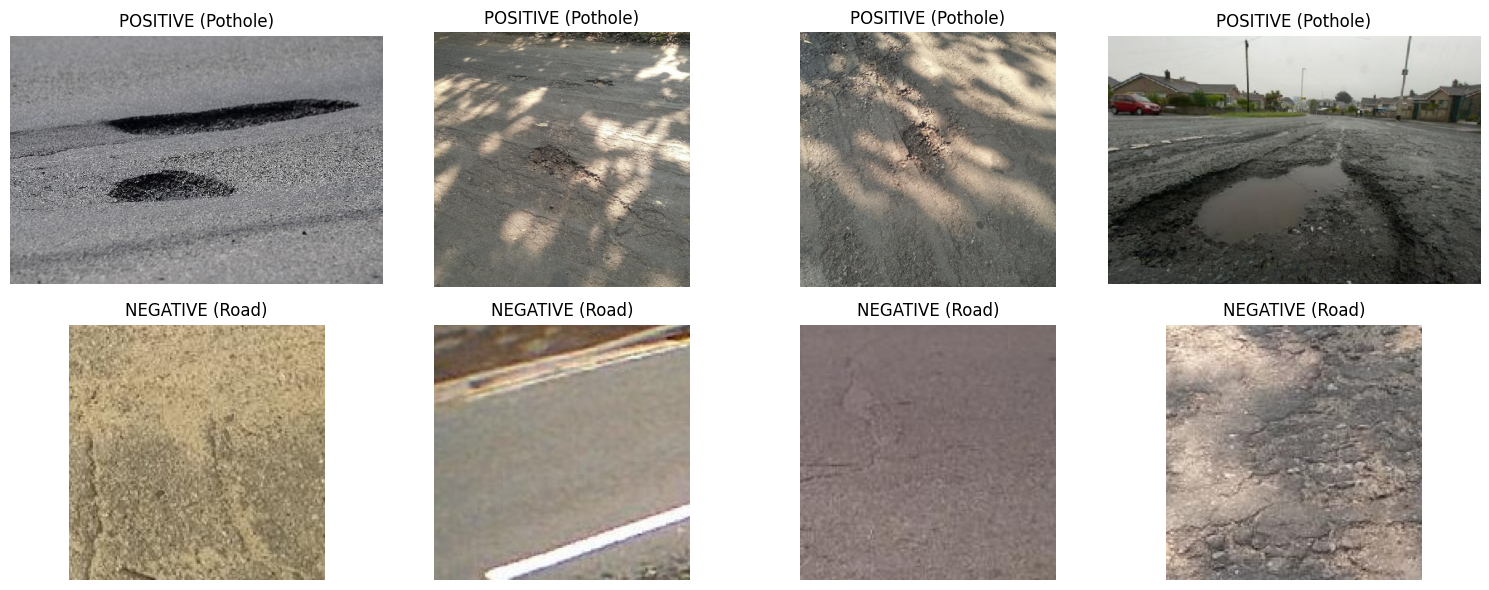

In [43]:
def plot_sample_data(df, num_samples=4):
    # Filter paths that actually exist
    pos_samples = df[df['Label'] == 'POSITIVE'].sample(num_samples)['Filepath'].values
    neg_samples = df[df['Label'] == 'NEGATIVE'].sample(num_samples)['Filepath'].values

    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        # Plot Positives (Full images or potholes)
        plt.subplot(2, num_samples, i + 1)
        img = cv2.cvtColor(cv2.imread(pos_samples[i]), cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title('POSITIVE (Pothole)')
        plt.axis('off')

        # Plot Negatives (Mined road patches)
        plt.subplot(2, num_samples, i + 1 + num_samples)
        img = cv2.cvtColor(cv2.imread(neg_samples[i]), cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title('NEGATIVE (Road)')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_data(all_df)

### Step 4.6 - Data Quality Check
Visualizing positive (pothole) and negative (road) samples to ensure they are distinct.

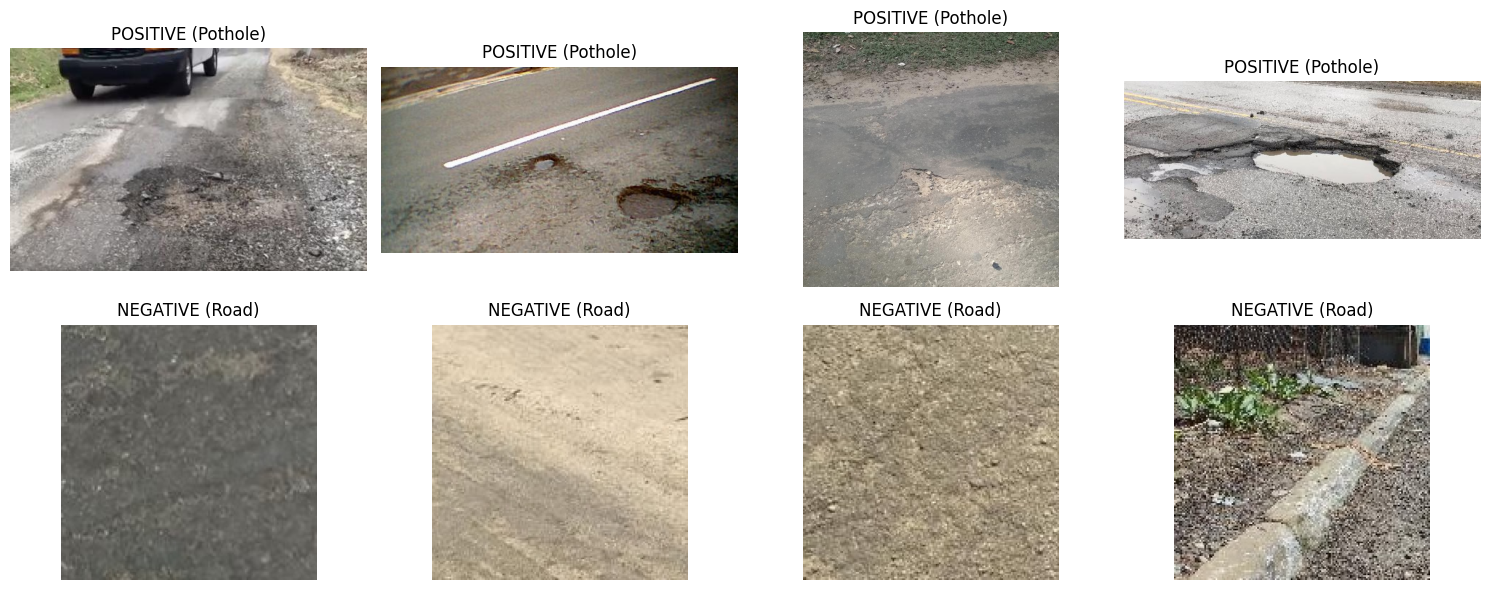

In [42]:
def plot_sample_data(df, num_samples=4):
    pos_samples = df[df['Label'] == 'POSITIVE'].sample(num_samples)['Filepath'].values
    neg_samples = df[df['Label'] == 'NEGATIVE'].sample(num_samples)['Filepath'].values

    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        # Plot Positives
        plt.subplot(2, num_samples, i + 1)
        img = cv2.cvtColor(cv2.imread(pos_samples[i]), cv2.COLOR_BGR2RGB)
        plt.imshow(img); plt.title('POSITIVE (Pothole)'); plt.axis('off')

        # Plot Negatives
        plt.subplot(2, num_samples, i + 1 + num_samples)
        img = cv2.cvtColor(cv2.imread(neg_samples[i]), cv2.COLOR_BGR2RGB)
        plt.imshow(img); plt.title('NEGATIVE (Road)'); plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_data(all_df)

# ============================================================
# STEP 5 - TRAIN TEST SPLIT
# ============================================================


In [45]:
# Split the new patch-based dataframe
train_df, test_df = train_test_split(
    all_df,
    train_size=0.8,
    shuffle=True,
    random_state=42,
    stratify=all_df['Label']
)

# Further split train into train and validation
train_df_final, val_df = train_test_split(
    train_df,
    train_size=0.8,
    shuffle=True,
    random_state=42,
    stratify=train_df['Label']
)

print(f'✅ Patches for Training: {len(train_df_final)}')
print(f'✅ Patches for Validation: {len(val_df)}')
print(f'✅ Patches for Testing: {len(test_df)}')

✅ Patches for Training: 1686
✅ Patches for Validation: 422
✅ Patches for Testing: 527


# ============================================================
# STEP 6 - DATA GENERATORS
# ============================================================


In [39]:
train_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, rotation_range=15, horizontal_flip=True, zoom_range=0.1)
test_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(train_df_final, x_col='Filepath', y_col='Label', target_size=(160,160), class_mode='binary', batch_size=32)
val_data = test_gen.flow_from_dataframe(val_df, x_col='Filepath', y_col='Label', target_size=(160,160), class_mode='binary', batch_size=32)
test_data = test_gen.flow_from_dataframe(test_df, x_col='Filepath', y_col='Label', target_size=(160,160), class_mode='binary', batch_size=32, shuffle=False)

Found 372 validated image filenames belonging to 2 classes.
Found 93 validated image filenames belonging to 2 classes.
Found 200 validated image filenames belonging to 2 classes.


# ============================================================
# STEP 7 - BUILD CNN MODEL
# ============================================================


In [38]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(160,160,3), include_top=False, weights='imagenet')
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# ============================================================
# STEP 8 - TRAIN MODEL
# ============================================================


In [46]:
# Re-initialize generators for the new dataframe
train_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True, fill_mode='nearest')
val_test_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(train_df_final, x_col='Filepath', y_col='Label', target_size=(160,160), class_mode='binary', batch_size=32)
val_data = val_test_gen.flow_from_dataframe(val_df, x_col='Filepath', y_col='Label', target_size=(160,160), class_mode='binary', batch_size=32)
test_data = val_test_gen.flow_from_dataframe(test_df, x_col='Filepath', y_col='Label', target_size=(160,160), class_mode='binary', batch_size=32, shuffle=False)

print('\n🚀 Phase 1: Training Head with uniform patches...')
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_data, validation_data=val_data, epochs=10)

print('\n🚀 Phase 2: Fine-Tuning...')
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_data, validation_data=val_data, epochs=15, callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)])

Found 1686 validated image filenames belonging to 2 classes.
Found 422 validated image filenames belonging to 2 classes.
Found 527 validated image filenames belonging to 2 classes.

🚀 Phase 1: Training Head with uniform patches...
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8037 - loss: 0.4221 - val_accuracy: 0.8152 - val_loss: 0.4039
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8754 - loss: 0.2883 - val_accuracy: 0.6564 - val_loss: 0.8373
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9093 - loss: 0.2357 - val_accuracy: 0.6445 - val_loss: 0.9893
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9170 - loss: 0.2047 - val_accuracy: 0.6754 - val_loss: 0.8655
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9395 - loss: 0.1621 - val_accuracy: 0.7251 - val_loss: 0.7206
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9407 - loss: 0.1554 - val_accuracy: 0.6777 - val_loss: 0.9059
Epoch 7/10
53

# ============================================================
# STEP 9 - PLOT ACCURACY & LOSS
# ============================================================


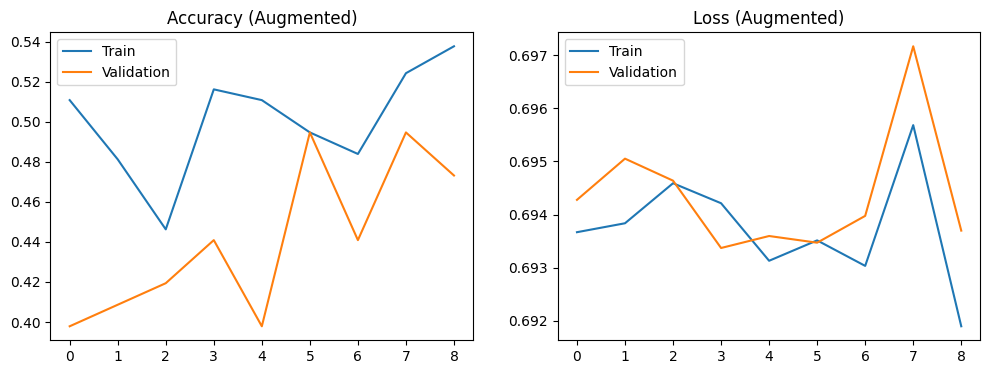

In [29]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy (Augmented)'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss (Augmented)'); plt.legend()
plt.show()

# ============================================================
# STEP 10 - TEST ACCURACY + CONFUSION MATRIX
# ============================================================


17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 664ms/step - accuracy: 0.8710 - loss: 0.3325

✅ FINAL TEST ACCURACY (Patch-Based): 87.10%
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 784ms/step


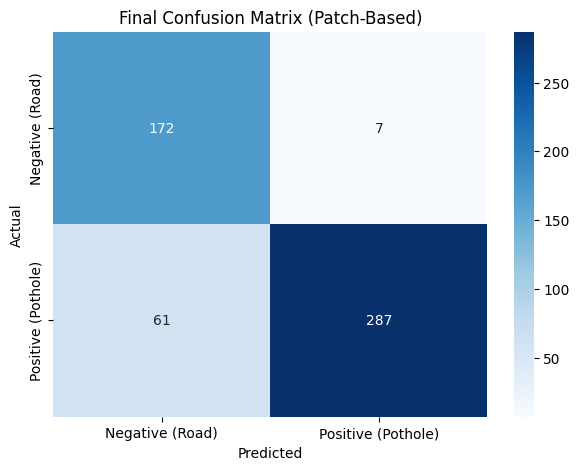

              precision    recall  f1-score   support

    Negative       0.74      0.96      0.83       179
    Positive       0.98      0.82      0.89       348

    accuracy                           0.87       527
   macro avg       0.86      0.89      0.86       527
weighted avg       0.90      0.87      0.87       527



In [47]:
results = model.evaluate(test_data)
print(f"\n✅ FINAL TEST ACCURACY (Patch-Based): {results[1]*100:.2f}%")

# Predict and plot Confusion Matrix
pred_probs = model.predict(test_data)
pred = (pred_probs > 0.5).astype(int).flatten()
true = test_data.classes

cm = confusion_matrix(true, pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (Road)', 'Positive (Pothole)'],
            yticklabels=['Negative (Road)', 'Positive (Pothole)'])
plt.title('Final Confusion Matrix (Patch-Based)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(true, pred, target_names=['Negative', 'Positive']))

# ============================================================
# STEP 11 - SAVE MODEL
# ============================================================


In [26]:
model.save('/content/crack_model.h5')
print("✅ Model saved as crack_model.h5")

from google.colab import files
try:
    files.download('/content/crack_model.h5')
    print("✅ Model download triggered!")
except Exception as e:
    print(f"☁️ Download failed: {e}")

✅ Model saved as crack_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model download triggered!
